# 04 Example:  Force due to a charge

An insulating cylinder of length 1 m and diameter 2 cm has a surface charge of 100$\mu\rm{C}$ uniformly distributed over the surface.  Calculate the force on a 50$\mu\rm{C}$ point charge at an arbitrary position in space.  Define the origin as the center of the cylinder, with the axis of the cylinder along the z-axis.

Plot the x and z components of the force for a) point charge is in the x-y plane ie. has position(x,y, 0),
as well as for the case z=1m.  

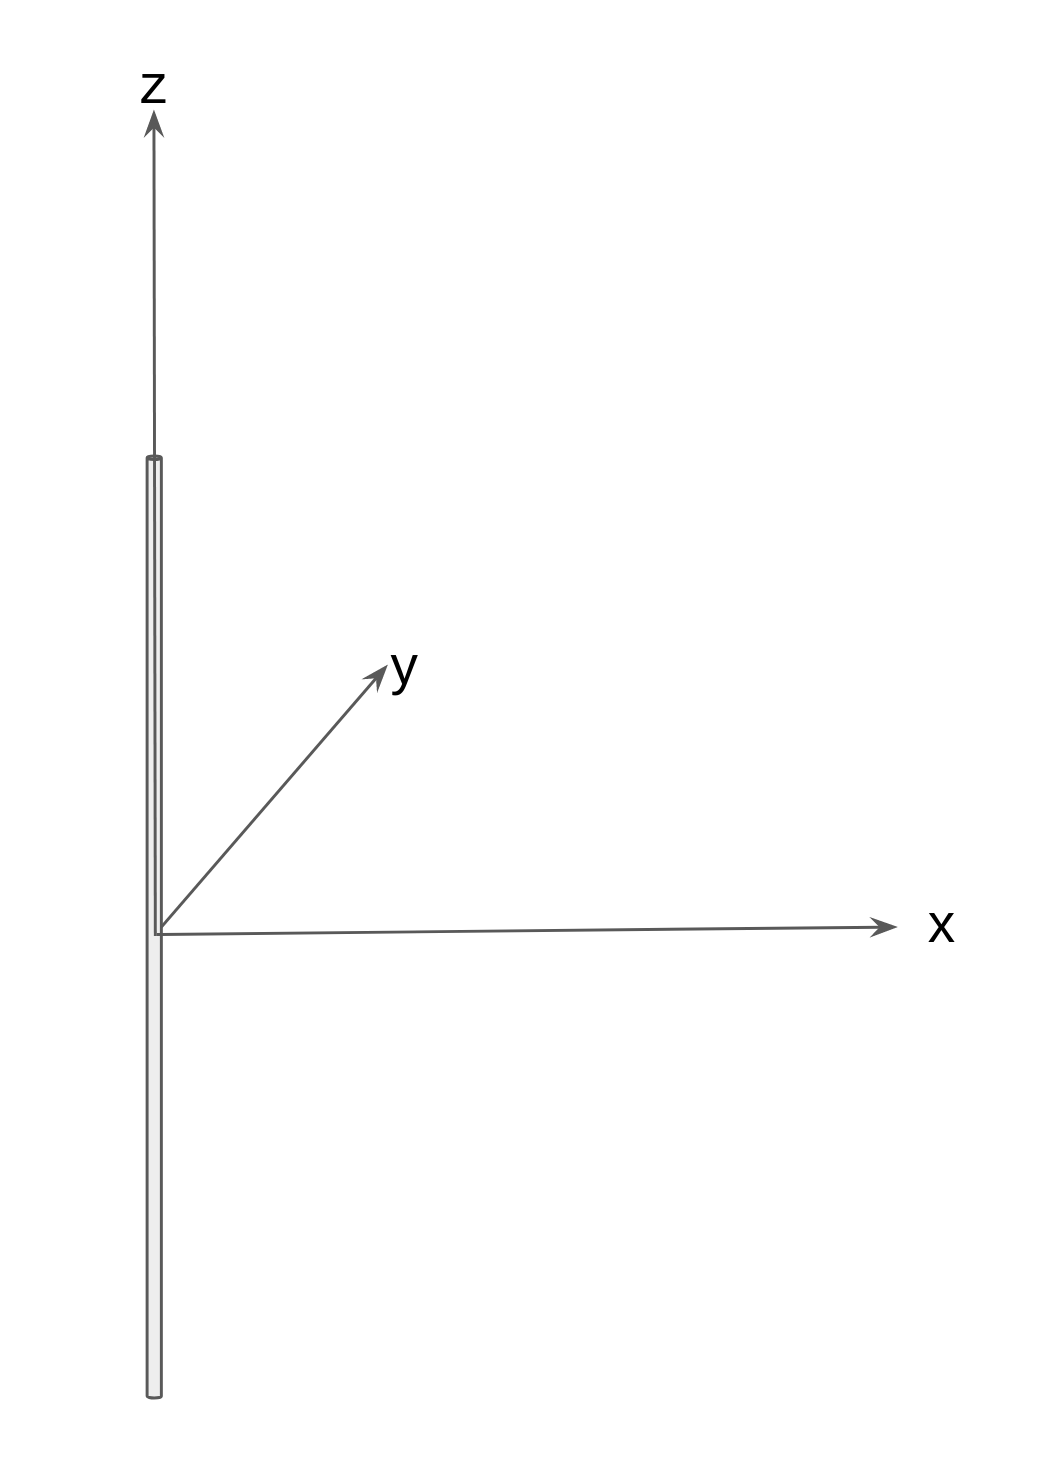

Always start a problem by summarizing three things in *words*:
1. Physics (What are the underlying principles?)




2. Numerics (How we should go about calculating it with a computer?)




3. Validation calculations










My answers:
1. Physics:
The force on a stationary charge is determined by the electric field:  $$\vec{F}=q\vec{E},$$ Coulomb's law. Since the charges are distributed in space, we will use the principle of superposition-- ie, we find the field by integrating over the charge distribution $\sigma dA$, where $dA$ is a small element of the charge distribution.   
2.  How we should go about calculating it?

We have the choice between finding the field:
directly using Coulomb's law: $$\vec{E}(\vec{r})=\frac{1}{4\pi\epsilon_0}\frac{dq (\vec{r}-\vec{r'})}{|\vec{r}-\vec{r'}|^3}$$ where $\vec {r'}$ refers to the position of the element of charge on the surface of they cylinder, and $\vec{r}$ the location at which we want to know the field.  
We can also find the electric potential $$V(\vec{r})=\frac{1}{4\pi\epsilon_0}\frac{dq}{|\vec{r}-\vec{r'}|},$$ and then using the gradient to get the electric field  $$\vec{E}=-\vec{\nabla}V.$$

Integrating the charge will be a 2d integral of a vector field over the surface area, while finding the potential will by a 2d integral of a scalar.  The derivatives are easy.  The difference between the two techniques is pretty small, but we will pick the potential as the way to do it; using dblquad- double because we are integrating over the surface area.  If we were to integrate the vector field, we would need to do quad_vec in a nested way- first integrating over one variable and then the other.

3.  Validation calculations
When we are very far away, our calculation should become the force between two point charges, so we should check that limit.

Along the z-axis the integrals are analytic, so we should compare our calculation with the analytic ones.  



In [48]:
import scipy
help(scipy.constants)

Help on package scipy.constants in scipy:

NAME
    scipy.constants

DESCRIPTION
    Constants (:mod:`scipy.constants`)
    
    .. currentmodule:: scipy.constants
    
    Physical and mathematical constants and units.
    
    
    Mathematical constants
    
    ================  =================================================================
    ``pi``            Pi
    ``golden``        Golden ratio
    ``golden_ratio``  Golden ratio
    ================  =================================================================
    
    
    Physical constants
    
    ===========================  =================================================================
    ``c``                        speed of light in vacuum
    ``speed_of_light``           speed of light in vacuum
    ``mu_0``                     the magnetic constant :math:`\mu_0`
    ``epsilon_0``                the electric constant (vacuum permittivity), :math:`\epsilon_0`
    ``h``                        the Planck cons

In [49]:
import numpy as np
from scipy.integrate import dblquad, quad_vec
from scipy.constants import epsilon_0,pi #in SI units
CoulombFactor=1.0/(4*pi*epsilon_0)
chargeOnBar=100e-6 #Coulombs
rhoBar=0.01 #meters radius
zBar=1.0 #meters length
areaBar=2*pi*rhoBar**2+2*pi*rhoBar*zBar
sigma=chargeOnBar/areaBar #charge per unit area on bar

#integrand for voltage due to charge on the ends-- want to integrate over rho, phi
def V1(phi,rho,z,r):  #note dblquad wants func(y,x).  
    '''An integrand for the calculation of electrical potential from the end of a cylinder along the z axis
    Inputs phi,rho are the cylindrical position of the charge creating the field in a form to input to dblquad
    Input z is the position of the end.
    Input r is the position at which the field is evaluated.  It is a vector in cartesian coordinates.
    Output is the electric potential due to a charge distribution with charge per unit area sigma.'''
    rprime=np.array([rho*np.cos(phi),rho*np.sin(phi),z])
    distance=np.linalg.norm(r-rprime)
    return CoulombFactor*sigma*rho/distance #implicit drho dphi

#integrand for voltage due to charge on cylindrical surface- want to integrate over phi, z
def V2(z,phi,rho,r):
    '''An integrand for the calculation of electrical potential from a cylindrical surface along the z axis
    Inputs z,phi are the cylindrical position of the charge creating the field in a form to input to dblquad
    Input rho is the radius of the cylinder.
    Input r is the position at which the field is evaluated.  It is a vector in cartesian coordinates.
    Output is the electric potential due to a charge distribution with charge per unit area sigma.'''
    rprime=np.array([rho*np.cos(phi),rho*np.sin(phi),z])
    distance=np.linalg.norm(r-rprime)
    return CoulombFactor*sigma*rho/distance #implicit dphi dz

def V(r):
    '''Calculates electric potential at a point r from a cylinder
    Input r is the position where we evaluate the field, as a vector
    Output is the electric potential'''
    v=(dblquad(V1,0,rhoBar,0,2*pi,args=(-zBar/2.0,r))[0]+ 
    dblquad(V1,0,rhoBar,0,2*pi,args=(zBar/2.0,r))[0]+
    dblquad(V2,0,2*pi,-zBar/2.0,zBar/2,args=(rhoBar,r))[0])
    return v

def E(r):
    '''Calculates the Vector Electric field at position r'''
    global dx,dy,dz
    dx=5e-6*np.array([1,0,0]) #step size for integral
    dy=5e-6*np.array([0,1,0]) #step size for integral
    dz=5e-6*np.array([0,0,1]) #step size for integral
    rplus=r+dx
    rminus=r-dx
    E1=-(V(rplus)-V(rminus))/(rplus[0]-rminus[0])
    rplus=r+dy
    rminus=r-dy
    E2=-(V(rplus)-V(rminus))/(rplus[1]-rminus[1])
    rplus=r+dz
    rminus=r-dz
    E3=-(V(rplus)-V(rminus))/(rplus[2]-rminus[2])
    return np.array([E1,E2,E3])
    
def Ex(r):
    'Calculate X component of Efield at position r'
    dx=5e-6*np.array([1,0,0]) #step size for integral
    rplus=r+dx
    rminus=r-dx
    xE=-(V(rplus)-V(rminus))/(rplus[0]-rminus[0])
    return xE

def Ez(r):
    'Calculate Z component of Efield at position r'
    dz=5e-6*np.array([0,0,1]) #step size for integral
    rplus=r+dz
    rminus=r-dz
    zE=-(V(rplus)-V(rminus))/(rplus[2]-rminus[2])
    return zE


In [53]:
#print some values just to see that the code works
r=np.array([0,0,-1])

print(r, E(r))
rplus=r+dx
print(V(rplus))
rminus=r-dx
print(V(rminus))


[ 0  0 -1] [      -0.               -0.         -1205902.01904207]
989392.1572988636
989392.1572988636


Now, let's plot the voltage and the x,z components of the field. Since the field is cylindrically symmetric, this is the same as plotting $\rho,z$ components.

If we create a 2d array, python lets us plot it with the plt.imshow() function.

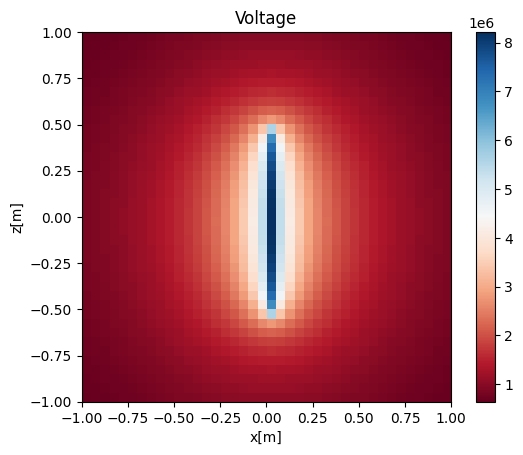

In [54]:
import matplotlib.pyplot as plt #import meshgrid,cm,imshow,contour,clabel,colorbar,axis,title,show

def voltage(x,z):
    r=np.array([x,0,z])
    return V(r)
x = np.arange(-1.0,1.0,0.05)
z = np.arange(-1.0,1.0,0.05)
X,Z = np.meshgrid(x, z) # grid of point
volt2=np.vectorize(voltage)
VV = volt2(X,Z) # evaluation of the function on the grid

im = plt.imshow(VV,cmap=plt.cm.RdBu,extent=[-1,1,-1,1],origin='lower') # drawing the function
plt.colorbar(im) # adding the colobar on the right
plt.title('Voltage')
plt.xlabel("x[m]")
plt.ylabel("z[m]")
plt.show()


In [57]:
Z


array([[-1.  , -1.  , -1.  , ..., -1.  , -1.  , -1.  ],
       [-0.95, -0.95, -0.95, ..., -0.95, -0.95, -0.95],
       [-0.9 , -0.9 , -0.9 , ..., -0.9 , -0.9 , -0.9 ],
       ...,
       [ 0.85,  0.85,  0.85, ...,  0.85,  0.85,  0.85],
       [ 0.9 ,  0.9 ,  0.9 , ...,  0.9 ,  0.9 ,  0.9 ],
       [ 0.95,  0.95,  0.95, ...,  0.95,  0.95,  0.95]])

In [58]:
X

array([[-1.  , -0.95, -0.9 , ...,  0.85,  0.9 ,  0.95],
       [-1.  , -0.95, -0.9 , ...,  0.85,  0.9 ,  0.95],
       [-1.  , -0.95, -0.9 , ...,  0.85,  0.9 ,  0.95],
       ...,
       [-1.  , -0.95, -0.9 , ...,  0.85,  0.9 ,  0.95],
       [-1.  , -0.95, -0.9 , ...,  0.85,  0.9 ,  0.95],
       [-1.  , -0.95, -0.9 , ...,  0.85,  0.9 ,  0.95]])

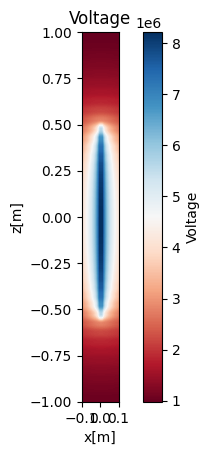

In [59]:
x = np.arange(-.10,.10,0.005)
z = np.arange(-1.0,1.0,0.05)
X,Z = np.meshgrid(x, z) # grid of point
volt2=np.vectorize(voltage)
VV = volt2(X,Z) # evaluation of the function on the grid

im = plt.imshow(VV,cmap=plt.cm.RdBu,extent=[-.1,.1,-1,1],origin='lower') # drawing the function
plt.colorbar(im,label="Voltage") # adding the colobar on the right
plt.title('Voltage')
plt.xlabel("x[m]")
plt.ylabel("z[m]")
plt.show()

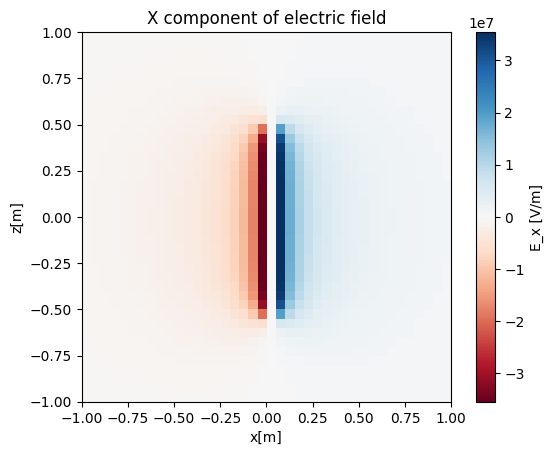

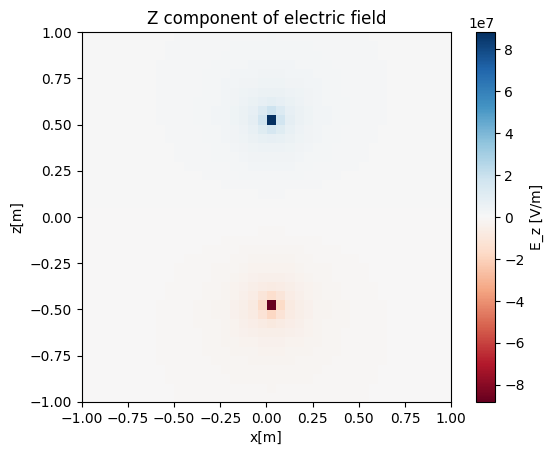

In [95]:
def XField(x,z):
    r=np.array([x,0,z])
    return Ex(r)
def ZField(x,z):
    r=np.array([x,0,z])
    return Ez(r)
x = np.arange(-1.0,1.0,0.05)
z= np.arange(-1.0,1.0,0.05)
X,Z = np.meshgrid(x, z) # grid of point
XF2=np.vectorize(XField)
ZF2=np.vectorize(ZField)

EX = XF2(X,Z) # evaluation of the function on the grid

im = plt.imshow(EX,cmap=plt.cm.RdBu,extent=[-1,1,-1,1]) # drawing the function
plt.colorbar(im,label='E_x [V/m]') # adding the colobar on the right
plt.xlabel("x[m]")
plt.ylabel("z[m]")
plt.title('X component of electric field')
plt.show()

EZ = ZF2(X,Z) # evaluation of the function on the grid

im = plt.imshow(EZ,cmap=plt.cm.RdBu,extent=[-1,1,-1,1],origin='lower') # drawing the function
plt.colorbar(im,label='E_z [V/m]') # adding the colobar on the right
plt.xlabel("x[m]")
plt.ylabel("z[m]")
plt.title('Z component of electric field')
plt.show()

In [94]:
Z

array([[-1.  , -1.  , -1.  , ..., -1.  , -1.  , -1.  ],
       [-0.95, -0.95, -0.95, ..., -0.95, -0.95, -0.95],
       [-0.9 , -0.9 , -0.9 , ..., -0.9 , -0.9 , -0.9 ],
       ...,
       [ 0.85,  0.85,  0.85, ...,  0.85,  0.85,  0.85],
       [ 0.9 ,  0.9 ,  0.9 , ...,  0.9 ,  0.9 ,  0.9 ],
       [ 0.95,  0.95,  0.95, ...,  0.95,  0.95,  0.95]])

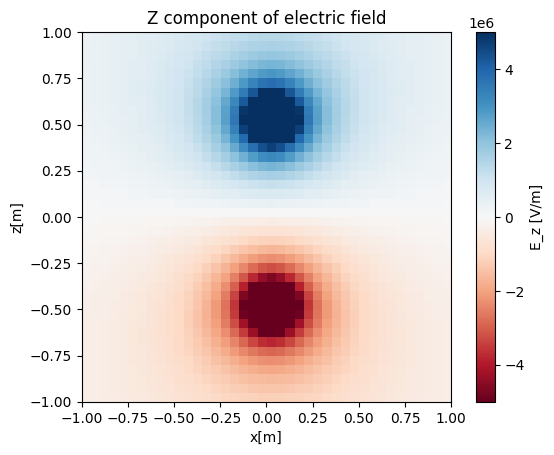

In [97]:
im = plt.imshow(EZ,cmap=plt.cm.RdBu,extent=[-1,1,-1,1],origin='lower',vmin=-5e6, vmax=5e6) # drawing the function
plt.colorbar(im,label='E_z [V/m]') # adding the colobar on the right
plt.xlabel("x[m]")
plt.ylabel("z[m]")
plt.title('Z component of electric field')
plt.show()

There are better ways to plot fields- field lines and equipotentials, and we will come back to those later.
It also takes a long time to plot, which can be alleviated by interpolation, which we will come back to as well.

But for now, let's do 1D plots of Voltage, Ex and Ez along the two axis x=0 and z=0.  

In [34]:
xpoints=np.linspace(-5,5)
rlist=[np.array([x,0,0]) for x in xpoints]  #3D points along x axis
vxpoints=[V(r) for r in rlist]
expoints=[Ex(r) for r in rlist]
ezpoints=[Ez(r) for r in rlist]


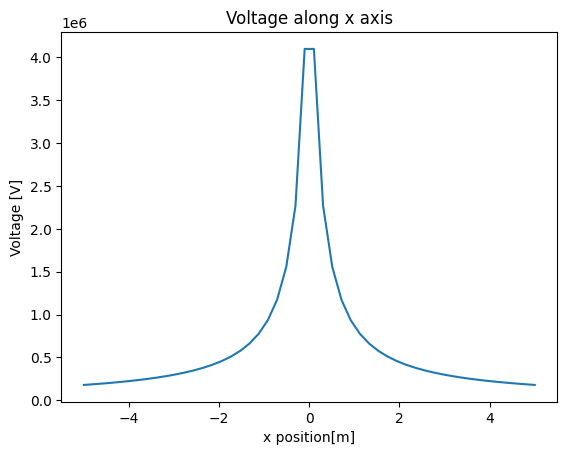

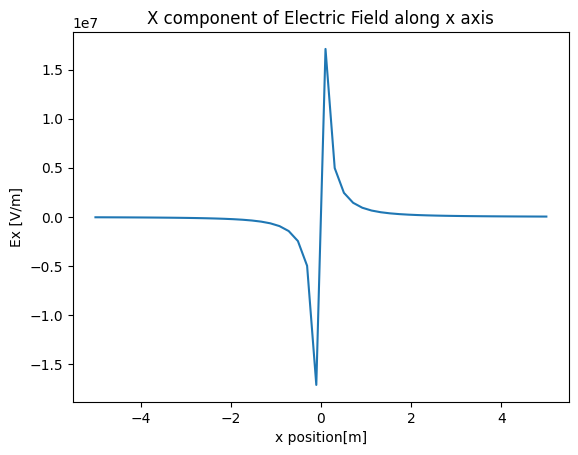

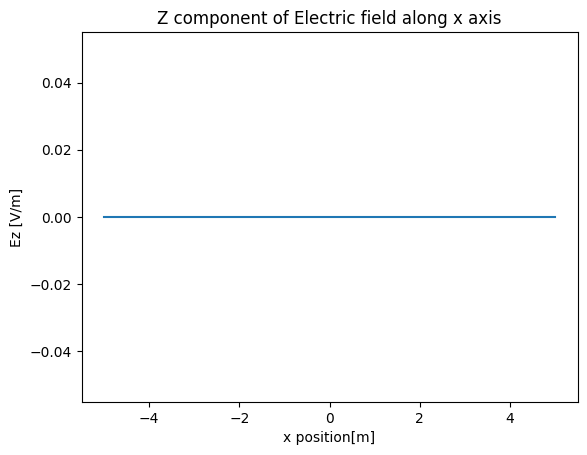

In [35]:
plt.plot(xpoints,vxpoints)
plt.title('Voltage along x axis')
plt.xlabel('x position[m]')
plt.ylabel('Voltage [V]')
plt.show()
plt.plot(xpoints,expoints)
plt.title('X component of Electric Field along x axis')
plt.xlabel('x position[m]')
plt.ylabel('Ex [V/m]')
plt.show()
plt.plot(xpoints,ezpoints)
plt.title('Z component of Electric field along x axis')
plt.xlabel('x position[m]')
plt.ylabel('Ez [V/m]')
plt.show()

In [36]:
rlist=[np.array([0,0,z]) for z in xpoints]  #3D points for x along z axis
vzpoints=[V(r) for r in rlist]
expoints2=[Ex(r) for r in rlist]
ezpoints2=[Ez(r) for r in rlist]


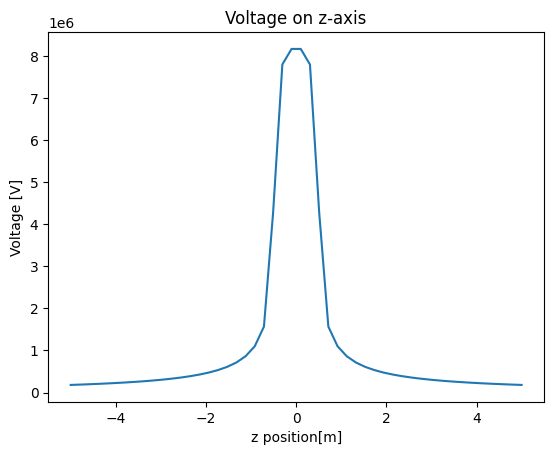

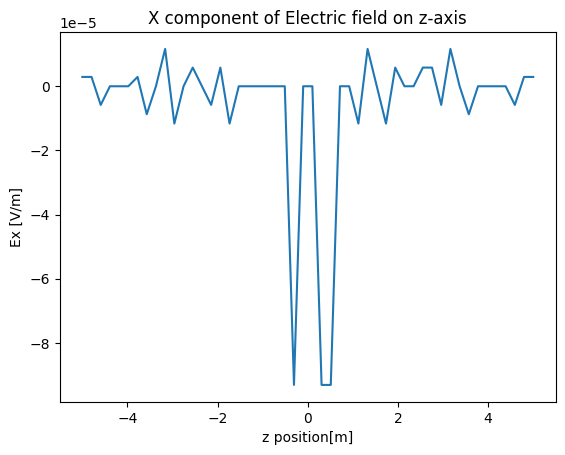

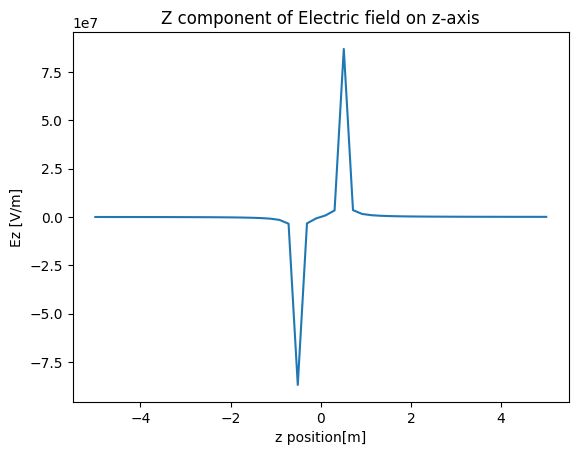

In [37]:
plt.plot(xpoints,vpoints2)
plt.title('Voltage on z-axis')
plt.xlabel('z position[m]')
plt.ylabel('Voltage [V]')
plt.show()
plt.plot(xpoints,expoints2)
plt.title('X component of Electric field on z-axis')
plt.xlabel('z position[m]')
plt.ylabel('Ex [V/m]')
plt.show()
plt.plot(xpoints,ezpoints2)
plt.title('Z component of Electric field on z-axis')
plt.xlabel('z position[m]')
plt.ylabel('Ez [V/m]')
plt.show()

Text(0, 0.5, 'Difference[V]')

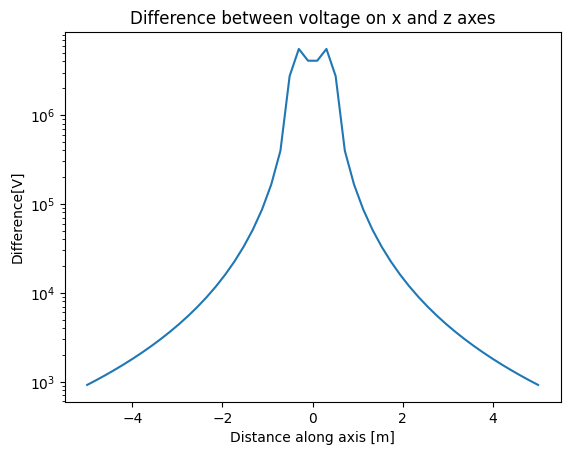

In [38]:
vzpoints=np.array(vzpoints)
vxpoints=np.array(vxpoints)
plt.plot(xpoints,vzpoints-vxpoints)
plt.yscale('log')
plt.title("Difference between voltage on x and z axes")
plt.xlabel("Distance along axis [m]")
plt.ylabel("Difference[V]")

## Validation 1:  Voltage agrees with analytic function as we get far away

If the rod were a point at the origin, the voltage would be $$V(\vec{r})=\frac{1}{4\pi\epsilon_0}\frac{q}{|\vec{r}|}$$

We will plot the difference between analytic and V, both along the x and z axes.

What does this check?

In [79]:
def VAnalytic(r):
    norm=np.linalg.norm(r)
    return CoulombFactor*chargeOnBar/norm  # note-- if we made a mistake in CoulombFactor or chargeOnBar both calculations will be wrong



In [80]:
xlist=np.logspace(0,3)
rlist=[np.array([x,0,0])for x in xlist]
vlistXAnalytic=np.array([VAnalytic(r) for r in rlist])
vlistX=np.array([V(r) for r in rlist])
rlist2=[np.array([0,0,z])for z in xlist]
vlistZAnalytic= np.array([VAnalytic(r) for r in rlist2])  #mathematically, this is the same as VlistXAnalytic
vlistZ=np.array([V(r) for r in rlist2])

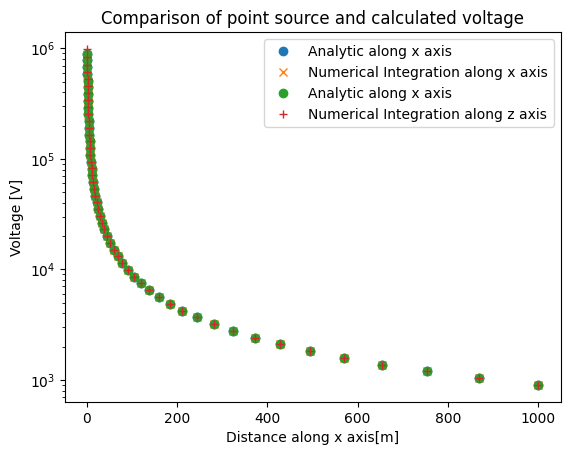

In [81]:
plt.plot(xlist,vlistXAnalytic,'o',label='Analytic along x axis')
plt.plot(xlist,vlistX,'x',label='Numerical Integration along x axis')
plt.plot(xlist,vlistXAnalytic,'o',label='Analytic along x axis')
plt.plot(xlist,vlistZ,'+',label='Numerical Integration along z axis')
plt.legend()
plt.title("Comparison of point source and calculated voltage")
plt.xlabel("Distance along x axis[m]")
plt.ylabel("Voltage [V]")
plt.yscale('log')

Text(0, 0.5, 'Voltage')

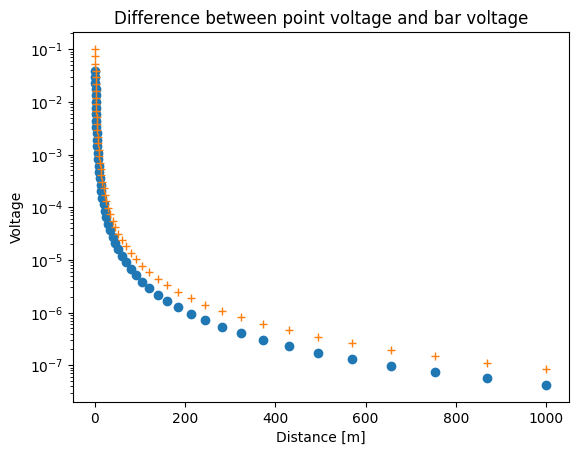

In [43]:
plt.plot(xlist,(-vlistX+vlistXAnalytic)/vlistXAnalytic,'o',label='Numerical Integration along x axis')
plt.plot(xlist,(vlistZ-vlistZAnalytic)/vlistZAnalytic,'+',label='Numerical Integration along z axis')
plt.yscale('log')
plt.title("Difference between point voltage and bar voltage")
plt.xlabel("Distance [m]")
plt.ylabel("Voltage")

## Voltage along axis
We can calculate the voltage analytically along the axis, at a point z.  For the two ends, we need to integrate the charge over a disk located at position $z_0$; for the rod we integrate the charge on the cylinder surface.

$$V_{end}(z)=\frac{1}{4\pi\epsilon_0}\int\frac{dq}{|\vec{r}|}=\frac{1}{4\pi\epsilon_0}\int_0^R \frac{\sigma 2\pi \rho d\rho} {\sqrt{(z-z_0)^2+\rho^2}}$$
$$=\frac{\sigma}{2\epsilon_0}\left(\sqrt{(z-z_0)^2+R^2}-(z-z_0)\right)$$

$$V_{cyl}(z)=\frac{1}{4\pi\epsilon_0}\int\frac{dq}{|\vec{r}|}=\frac{1}{4\pi\epsilon_0}\int_{-z_{bar}/2}^{z_{bar}/2} \frac{\sigma 2\pi R dz'} {\sqrt{(z-z')^2+R^2}}$$

$$=-\frac{\sigma R}{2\epsilon_0}\log{\left(\frac{z-z_{bar}/2+\sqrt{(z-z_{bar}/2)^2+R^2}}{z+z_{bar}/2+\sqrt{(z+z_{bar}/2)^2+R^2}}\right)}$$

In [82]:
def Vend(z,z0):
    return sigma/2/epsilon_0*(np.sqrt((z-z0)**2+rhoBar**2)-np.abs(z-z0))  #note-- I had sigma*rhoBar when I first wrote the function

def Vcyl(z):
    return -sigma*rhoBar/2/epsilon_0*np.log((np.sqrt((z-zBar/2)**2+rhoBar**2)+(z-zBar/2))/(np.sqrt((z+zBar/2)**2+rhoBar**2)+(z+zBar/2)))


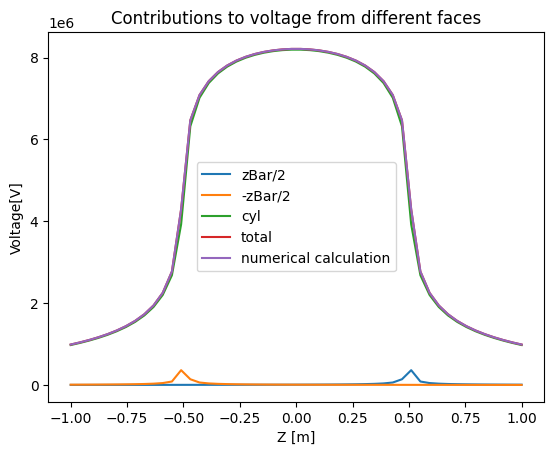

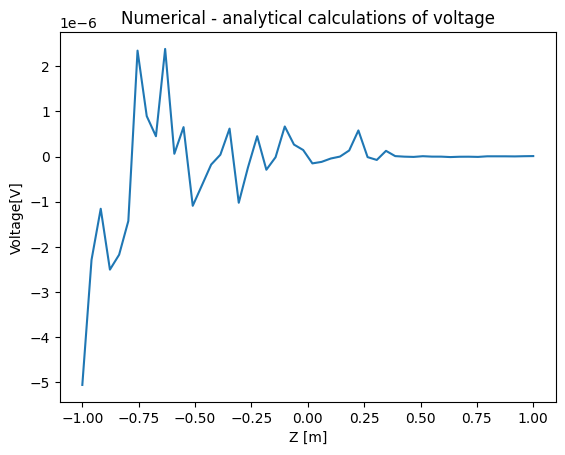

In [83]:
zlist=np.linspace(-1,1)
vlist=np.array([V(np.array([0,0,z]))for z in zlist])
plt.plot(zlist,Vend(zlist,zBar/2),label='zBar/2')
plt.plot(zlist,Vend(zlist,-zBar/2),label='-zBar/2')
plt.plot(zlist,Vcyl(zlist),label='cyl')
plt.plot(zlist,Vend(zlist,zBar/2)+Vend(zlist,-zBar/2)+Vcyl(zlist),label='total')
plt.plot(zlist,vlist,label='numerical calculation')
plt.legend()
plt.title('Contributions to voltage from different faces')
plt.ylabel('Voltage[V]')
plt.xlabel('Z [m]')
plt.show()
plt.title("Numerical - analytical calculations of voltage")
plt.ylabel('Voltage[V]')
plt.xlabel('Z [m]')
plt.plot(zlist,Vend(zlist,zBar/2)+Vend(zlist,-zBar/2)+Vcyl(zlist)-vlist)
plt.show()


Now we have validated our numerical calculation-- although we haven't totally removed all possible bugs.  
What haven't we tested?

Finally, we go back to our question:
An insulating cylinder of length 1 m and diameter 2 cm has a surface charge of 100 $\mu$C uniformly distributed over the surface.  Calculate the force on a 50 $\mu$C point charge at an arbitrary position in space.  Define the origin as the center of the cylinder, with the axis of the cylinder along the z-axis.

Plot the x and z components of the force for a) point charge is in the x-y plane ie. has position(x,y, 0),
as well as for the case z=1m.  

From the Electric field we get the Force by $\vec{F}=q\vec{E}=50\mu C \vec{E}.$

Our calculation is relatively slow, so we will split the force in the x and z components.  

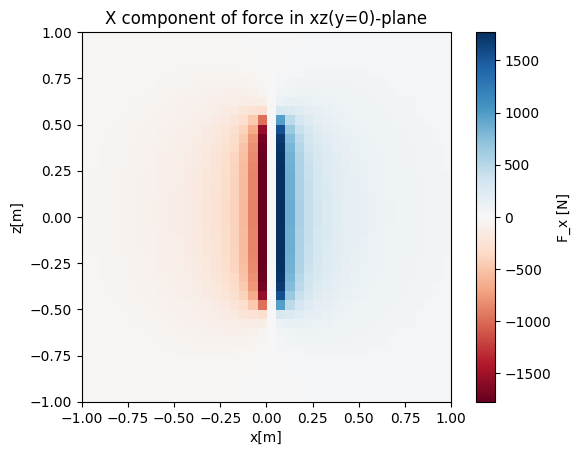

Text(0.5, 1.0, 'Z component of force in xz(y=0) plane')

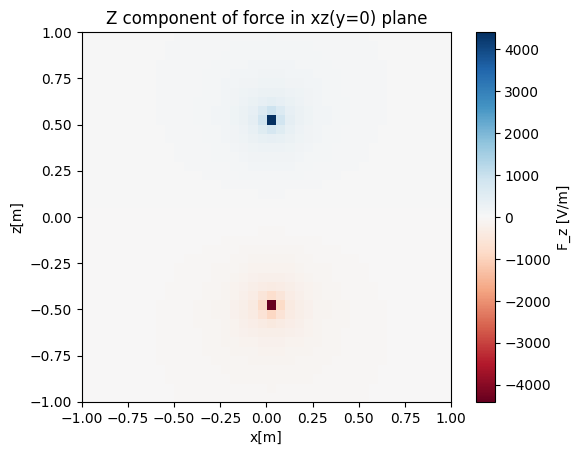

In [99]:
q=50e-6 # charge
def XForce(x,z):
    r=np.array([x,0,z])
    return q*Ex(r)
def ZForce(x,z):
    r=np.array([x,0,z])
    return q*Ez(r)
x = np.arange(-1.0,1.0,0.05)
y = np.arange(-1.0,1.0,0.05)
X,Y = np.meshgrid(x, y) # grid of point
XF2=np.vectorize(XForce)
ZF2=np.vectorize(ZForce)

Z = XF2(X,Y) # evaluation of the function on the grid

im = plt.imshow(Z,cmap=plt.cm.RdBu,extent=[-1,1,-1,1],origin='lower') # drawing the function
plt.title('X component of force in xz(y=0)-plane')
plt.colorbar(im,label='F_x [N]') # adding the colobar on the right
plt.xlabel("x[m]")
plt.ylabel("z[m]")

plt.show()

Z = ZF2(X,Y) # evaluation of the function on the grid

im = plt.imshow(Z,cmap=plt.cm.RdBu,extent=[-1,1,-1,1],origin='lower') # drawing the function
plt.colorbar(im,label='F_z [N]') # adding the colobar on the right
plt.xlabel("x[m]")
plt.ylabel("z[m]")

plt.title('Z component of force in xz(y=0) plane')


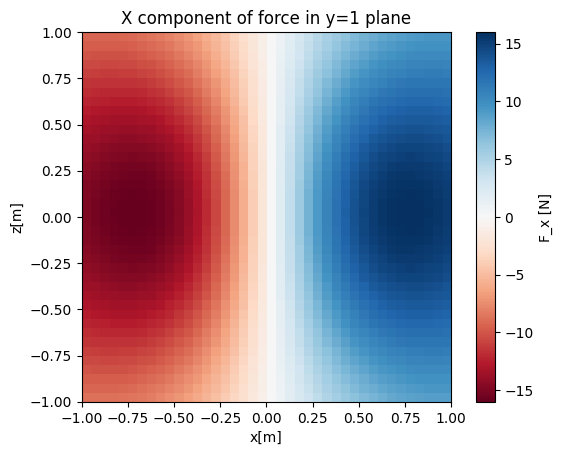

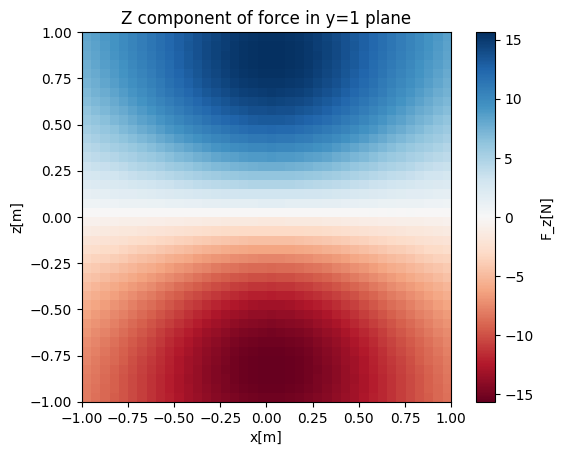

In [111]:
def XForce(x,z):
    r=np.array([x,1,z])
    return q*Ex(r)
def ZForce(x,z):
    r=np.array([x,1,z])
    return q*Ez(r)
x = np.arange(-1.0,1.0,0.05)
y = np.arange(-1.0,1.0,0.05)
X,Z = np.meshgrid(x, y) # grid of point
XF2=np.vectorize(XForce)
ZF2=np.vectorize(ZForce)

XF = XF2(X,Z) # evaluation of the function on the grid

im = plt.imshow(XF,cmap=plt.cm.RdBu,extent=[-1,1,-1,1],origin='lower') # drawing the function
plt.colorbar(im,label='F_x [N]') # adding the colobar on the right
plt.title('X component of force in y=1 plane')
plt.xlabel("x[m]")
plt.ylabel("z[m]")
plt.show()

ZF = ZF2(X,Z) # evaluation of the function on the grid

im = plt.imshow(ZF,cmap=plt.cm.RdBu,extent=[-1,1,-1,1],origin='lower') # drawing the function
plt.colorbar(im,label='F_z[N]') # adding the colobar on the right
plt.title('Z component of force in y=1 plane')
plt.xlabel("x[m]")
plt.ylabel("z[m]")
plt.show()